# 权重衰减：用 L2 正则化缓解过拟合

本节用一个刻意设计的高维线性回归实验观察过拟合，并通过权重衰减限制模型复杂度。代码从零实现 L2 惩罚，便于看清它如何进入损失函数、影响梯度，并最终让权重趋向较小的数值。

## 学习目标

完成本 notebook 后，应能解释：

- 为什么“样本少、特征多”容易过拟合；
- L2 正则化为什么倾向于得到更小的权重；
- 正则化强度 `lambd` 如何影响欠拟合与过拟合；
- 为什么本例只惩罚 `w`，不惩罚偏置 `b`；
- 手写 L2 惩罚与 PyTorch 优化器参数 `weight_decay` 的关系。

> 本 notebook 使用教材辅助函数，建议使用与教材匹配的 `d2l==0.17.6`。

## 1. 导入依赖

`%matplotlib inline` 让训练曲线直接显示在 notebook 中。`torch` 负责张量和自动微分，`d2l` 提供合成数据、线性回归、SGD、损失评估和动态绘图工具。当前代码导入了 `nn`，但这个从零实现暂未使用它。

In [3]:
%matplotlib inline
import torch
from torch import nn
from d2l import torch as d2l

## 2. 构造容易过拟合的数据

这个实验最关键的设置是：

| 配置 | 数值 | 含义 |
|---|---:|---|
| `n_train` | 20 | 训练样本非常少 |
| `n_test` | 100 | 用更多独立样本评估泛化 |
| `num_inputs` | 200 | 每个样本有 200 个特征 |
| `batch_size` | 5 | 每个 epoch 有 4 个训练批次 |

模型要根据 20 个样本学习 200 个权重和 1 个偏置，参数数量远多于训练样本。这样的模型很容易记住训练数据中的偶然噪声：训练损失很低，但测试损失较高，这就是过拟合。

数据由真实关系生成：

$$y=Xw^*+b^*+\epsilon$$

真实权重的每个元素都是 0.01，真实偏置是 0.05，$\epsilon$ 是合成数据中加入的随机噪声。`is_train=False` 使测试迭代器保持固定顺序；顺序不影响损失评估。

In [4]:
n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5
true_w, true_b = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train=False)

## 3. 初始化待学习参数

`w` 的形状是 `(200, 1)`，对应 200 个输入特征；`b` 是一个标量偏置。`requires_grad=True` 告诉 PyTorch 在反向传播时计算它们的梯度。

这里故意把 `w` 初始化为标准差为 1 的随机数，而真实权重只有 0.01。没有正则化时，高维模型可能保留较大的权重来拟合少量训练样本；加入权重衰减后，可以观察权重范数明显减小。每次调用 `train()` 都会重新调用 `init_params()`，所以两个实验分别从新的随机参数开始。

In [5]:
def init_params():
    w = torch.normal(0, 1, size=(num_inputs, 1), requires_grad=True)
    b = torch.zeros(1, requires_grad=True)
    return [w, b]

## 4. 定义 L2 惩罚项

L2 正则化把所有权重平方后求和：

$$\frac{1}{2}\lVert w\rVert_2^2=\frac{1}{2}\sum_i w_i^2$$

前面的 $1/2$ 是为了让求导结果更简洁：

$$\frac{\partial}{\partial w}\left(\frac{1}{2}\lVert w\rVert_2^2\right)=w$$

加入正则化后的优化目标为：

$$L_{total}=L_{data}+\lambda\frac{1}{2}\lVert w\rVert_2^2$$

因此权重梯度会额外增加 $\lambda w$。SGD 更新时会不断把权重向 0 拉近，这就是“权重衰减”这个名称的来源。

本例只惩罚权重 `w`，不惩罚偏置 `b`。偏置只整体平移预测值，通常对模型复杂度的影响较小；实际工程中也常将权重与偏置分成不同参数组，只对权重应用衰减。

In [6]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

## 5. 训练函数：把惩罚项加入目标函数

`lambd`（数学中常写作 $\lambda$）控制正则化强度：

- `lambd=0`：没有正则化；
- `lambd>0`：限制权重变大；
- 数值太大：模型可能过度压缩权重，导致欠拟合。

每个批次的核心过程是：

```python
prediction = net(X)
data_loss = loss(prediction, y)
total_loss = data_loss + lambd * l2_penalty(w)
total_loss.sum().backward()
d2l.sgd([w, b], lr, batch_size)
```

`squared_loss` 返回当前批次每个样本的损失向量，而 `l2_penalty(w)` 是标量。相加时，广播机制把同一个正则项加到每个样本的损失上。随后代码用 `l.sum().backward()` 求梯度，`d2l.sgd` 再除以 `batch_size`；因此最终正则项梯度的尺度仍对应 $\lambda w$。

绘图时评估的是原始平方损失 `loss`，没有把 L2 惩罚加入显示值。这样训练曲线直接反映模型对训练集和测试集的预测误差；最后打印的 $\lVert w\rVert_2$ 则单独显示正则化对权重大小的影响。纵轴使用对数刻度，便于同时观察不同数量级的损失。

In [7]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X: d2l.linreg(X, w, b), d2l.squared_loss
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (d2l.evaluate_loss(net, train_iter, loss),
                                     d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是：', torch.norm(w).item())

## 6. 对照实验一：不使用权重衰减

`lambd=0` 时，总损失中没有 L2 惩罚。高维模型可以使用较大的权重去贴合仅有的 20 个训练样本。观察时重点看两件事：

1. 训练损失与测试损失之间是否存在明显差距；
2. 最终权重的 L2 范数是否较大。

训练损失低并不自动意味着模型好；如果测试损失明显更高，说明模型记住了训练数据，却没有学到可泛化的规律。

w的L2范数是： 12.750739097595215


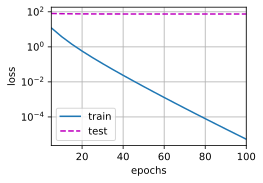

In [8]:
train(lambd=0)

## 7. 对照实验二：加入权重衰减

`lambd=3` 会在数据损失之外惩罚较大的权重。与上一组实验比较时，不应只看训练损失是否更低，而应观察：

- 训练损失与测试损失的差距是否缩小；
- 测试损失是否改善；
- 权重的 L2 范数是否显著下降。

当前保存的输出中，权重范数从未正则化时约 `13.52` 降到约 `0.35`，说明 L2 惩罚确实限制了权重大小。由于两次训练采用新的随机初始化，具体数字每次可能不同，应关注整体趋势而不是完全一致的数值。

w的L2范数是： 0.3657936751842499


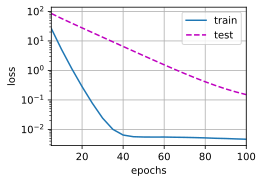

In [9]:
train(lambd=3)

## 8. 使用 PyTorch 简洁实现权重衰减

前面的从零实现显式计算 `lambd * l2_penalty(w)`，便于理解数学原理。实际项目通常让优化器通过 `weight_decay` 完成同样的权重收缩。

### 从零实现与简洁实现的对应关系

| 从零实现 | PyTorch 简洁实现 |
|---|---|
| 手动创建 `w、b` | `nn.Linear(num_inputs, 1)` |
| `d2l.linreg(X, w, b)` | `net(X)` |
| `d2l.squared_loss` | `nn.MSELoss(reduction='none')` |
| `lambd * l2_penalty(w)` | 优化器中的 `weight_decay=wd` |
| `l.sum().backward()` | `l.mean().backward()` |
| `d2l.sgd(...)` | `trainer.step()` |
| 更新后由教材函数清除梯度 | 更新前调用 `trainer.zero_grad()` |

`nn.Linear(200, 1)` 自动创建形状为 `(1, 200)` 的权重和形状为 `(1,)` 的偏置。它内部计算 $XW^T+b$，与手写版本中形状为 `(200, 1)` 的 `w` 计算 `X @ w + b` 数学等价，只是权重的存储方向不同。

### 参数初始化

`net.parameters()` 会返回 `Linear` 自动注册的权重和偏置。循环中的 `param.data.normal_()` 直接把两者都初始化为标准正态分布。它与手写版本不完全相同：手写版本将 `w` 随机初始化、`b` 初始化为 0。这个差异不影响权重衰减概念的对照，但会使每次运行的具体数值有所变化。

### 用参数组只衰减权重

优化器接收两个参数组：

```python
[
    {'params': net[0].weight, 'weight_decay': wd},
    {'params': net[0].bias}
]
```

第一组显式设置权重衰减；第二组没有设置，继承优化器默认值 `weight_decay=0`，所以偏置不衰减。这与手写实现只把 `w` 传给 `l2_penalty` 完全对应。

对于这里的 SGD，`weight_decay=wd` 会在更新时给权重梯度增加 `wd * weight`。因此代码不再把正则项显式添加到 `loss` 中。训练曲线仍只显示数据拟合误差。

### 训练循环的尺度对应

简洁实现使用 `l.mean().backward()`，因此梯度已经按批次大小取平均；内置 `trainer.step()` 可以直接更新参数。手写实现使用 `l.sum().backward()`，再由 `d2l.sgd(..., batch_size)` 除以批次大小。两者在数据损失的梯度尺度上对应。

In [10]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))
    for param in net.parameters():
        param.data.normal_()
    loss = nn.MSELoss(reduction='none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {"params":net[0].weight,'weight_decay': wd},
        {"params":net[0].bias}], lr=lr)
    animator = d2l.Animator(xlabel='epochs', ylabel='loss', yscale='log',
                            xlim=[5, num_epochs], legend=['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l = loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1,
                         (d2l.evaluate_loss(net, train_iter, loss),
                          d2l.evaluate_loss(net, test_iter, loss)))
    print('w的L2范数：', net[0].weight.norm().item())

### 简洁实现对照一：`weight_decay=0`

这组实验关闭优化器的权重衰减，对应前面的 `train(lambd=0)`。模型只有 20 个训练样本却有 200 个权重，容易得到较大的权重范数，并出现训练误差与测试误差之间的明显差距。

w的L2范数： 13.75790023803711


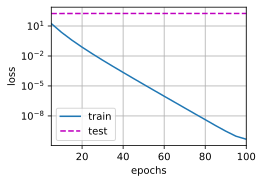

In [11]:
train_concise(0)

### 简洁实现对照二：`weight_decay=3`

这组实验只对 `net[0].weight` 应用强度为 3 的权重衰减，对应前面的 `train(lambd=3)`。当前保存的结果中，权重范数从约 `13.76` 降至约 `0.39`。这与手写实现观察到的趋势一致，说明两种 API 都有效限制了权重大小。

两套实现的具体范数不会完全相同，因为每次调用训练函数都会重新随机初始化参数，而且简洁实现还把偏置初始化为随机值。判断实验是否符合预期，应比较损失曲线差距和权重范数的数量级变化，而不是要求数值逐位一致。

w的L2范数： 0.39064887166023254


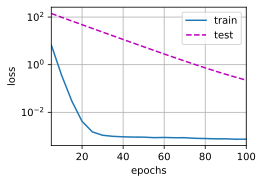

In [12]:
train_concise(3)


## 9. 实现选择与复习

从零实现适合理解 L2 惩罚如何改变目标函数和梯度；基于 `nn.Module` 与优化器参数组的简洁实现更接近实际项目。两者的核心目标相同：在拟合数据的同时限制权重过大。

> 对 Adam 等自适应优化器，传统 L2 正则与解耦权重衰减并不总是等价。实际项目通常使用 `AdamW` 明确实现解耦权重衰减。

### 复习清单

- 为什么 20 个样本学习 200 个特征权重容易过拟合？
- L2 惩罚的梯度为什么是 $w$？
- `lambd` 与 `weight_decay` 在本例中分别在哪里起作用？
- 为什么优化器需要把权重和偏置拆成两个参数组？
- 手写实现为何使用 `sum()`，简洁实现为何使用 `mean()`？
- 为什么评估损失时不把正则项计算进去？

### 小练习

1. 分别尝试 `wd=0.1、1、10`，记录测试损失和权重范数。
2. 打印 `net[0].weight.shape` 和 `net[0].bias.shape`，与手写参数形状比较。
3. 给偏置参数组也设置 `weight_decay=wd`，观察结果差异。
4. 将简洁实现中的偏置显式初始化为 0，使两套实现的初始条件更接近。
5. 将 `n_train` 增加到 100 或将 `num_inputs` 降到 20，观察无衰减时过拟合是否减轻。